In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

data = pd.read_csv("/content/drive/MyDrive/Dataset/creditcard_2023.csv")
data.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [ ]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [ ]:
pd.set_option("display.float", "{:.2f}".format)
data.describe()



,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,...,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00
mean,284314.50,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,...,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,12041.96,0.50
std,164149.49,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,6919.64,0.50
min,0.00,-3.50,-49.97,-3.18,-4.95,-9.95,-21.11,-4.35,-10.76,-3.75,...,-19.38,-7.73,-30.30,-4.07,-13.61,-8.23,-10.50,-39.04,50.01,0.00
25%,142157.25,-0.57,-0.49,-0.65,-0.66,-0.29,-0.45,-0.28,-0.19,-0.57,...,-0.17,-0.49,-0.24,-0.65,-0.55,-0.63,-0.30,-0.23,6054.89,0.00
50%,284314.50,-0.09,-0.14,0.00,-0.07,0.08,0.08,0.23,-0.11,0.09,...,-0.04,-0.03,-0.06,0.02,-0.01,-0.01,-0.17,-0.01,12030.15,0.50
75%,426471.75,0.83,0.34,0.63,0.71,0.44,0.50,0.53,0.05,0.56,...,0.15,0.46,0.16,0.70,0.55,0.67,0.33,0.41,18036.33,1.00
max,568629.00,2.23,4.36,14.13,3.20,42.72,26.17,217.87,5.96,20.27,...,8.09,12.63,31.71,12.97,14.62,5.62,113.23,77.26,24039.93,1.00


In [ ]:

data.isnull().sum().sum()


np.int64(0)

In [ ]:

data.columns



Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:

LABELS = ["Normal", "Fraud"]

count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency");





In [ ]:

data.Class.value_counts()


,count
Class,
0,284315
1,284315


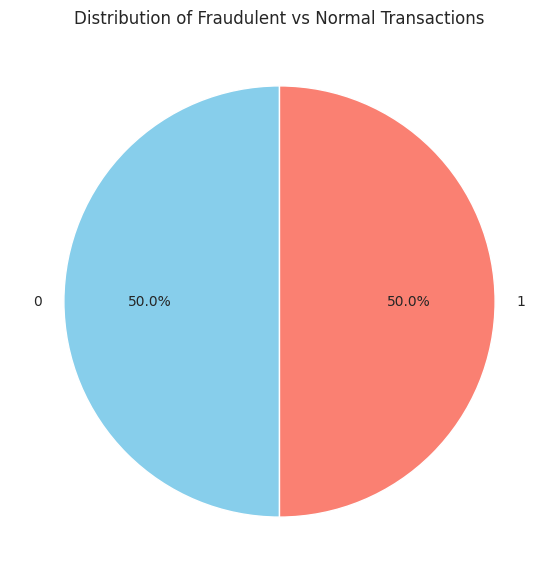

In [ ]:
import matplotlib.pyplot as plt

# Use the correct DataFrame name
status_counts = data['Class'].value_counts()

# Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Distribution of Fraudulent vs Normal Transactions')
plt.show()


In [ ]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]

print(f"Shape of Fraudulant transactions: {fraud.shape}")
print(f"Shape of Non-Fraudulant transactions: {normal.shape}")

Shape of Fraudulant transactions: (284315, 31)
Shape of Non-Fraudulant transactions: (284315, 31)


In [ ]:
pd.concat([fraud.Amount.describe(), normal.Amount.describe()], axis=1)

,Amount,Amount
count,284315.00,284315.00
mean,12057.60,12026.31
std,6909.75,6929.50
min,50.01,50.12
25%,6074.64,6034.54
50%,12062.45,11996.90
75%,18033.78,18040.26
max,24039.93,24039.93


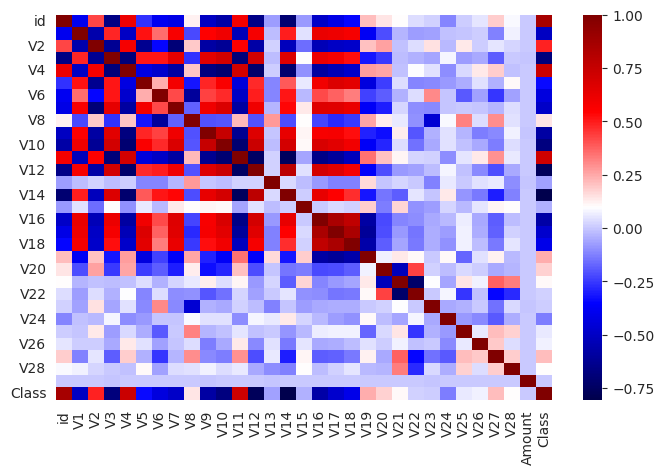

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(data=data.corr(), cmap="seismic")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X = data.drop('Class', axis=1)
y = data.Class

X_train_v, X_test, y_train_v, y_test = train_test_split(X, y,
                                                    test_size=0.3, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train_v, y_train_v,
                                                            test_size=0.2, random_state=42)

X_train = scalar.fit_transform(X_train)
X_validate = scalar.transform(X_validate)
X_test = scalar.transform(X_test)

w_p = y_train.value_counts()[0] / len(y_train)
w_n = y_train.value_counts()[1] / len(y_train)

print(f"Fraudulant transaction weight: {w_n}")
print(f"Non-Fraudulant transaction weight: {w_p}")

Fraudulant transaction weight: 0.499846120992865
Non-Fraudulant transaction weight: 0.5001538790071349


In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

# 3. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. First split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Second split: train vs validation
X_train, X_validate, y_train, y_validate = train_test_split(
    X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=42
)

# 6. Print shapes for verification
print(f"TRAINING:   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"VALIDATION: X_validate: {X_validate.shape}, y_validate: {y_validate.shape}")
print(f"TESTING:    X_test: {X_test.shape}, y_test: {y_test.shape}")


In [ ]:
from sklearn.preprocessing import StandardScaler

X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, confusion_matrix, log_loss

# 1. Split data into training, validation and test sets
X = data.drop('Class', axis=1)
y = data['Class']

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Split: training and validation sets (used in cross-validation loop below)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store training history manually
history = {
    'loss': [],
    'precision': [],
    'recall': [],
    'fn': [],
    'tp': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_fn': [],
    'val_tp': [],
}

# Compute class weights
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_val)
class_weight_dict = dict(zip(classes, class_weights))

# Cross-validation to simulate training history
for train_index, val_index in skf.split(X_train_val, y_train_val):
    X_train, X_val = X_train_val[train_index], X_train_val[val_index]
    y_train, y_val = y_train_val.iloc[train_index], y_train_val.iloc[val_index]

    model = LogisticRegression(max_iter=1000, class_weight=class_weight_dict)
    model.fit(X_train, y_train)

    # Training predictions
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    cm_train = confusion_matrix(y_train, y_train_pred)
    tn, fp, fn, tp = cm_train.ravel()

    history['loss'].append(log_loss(y_train, y_train_proba))
    history['precision'].append(precision_score(y_train, y_train_pred))
    history['recall'].append(recall_score(y_train, y_train_pred))
    history['fn'].append(fn)
    history['tp'].append(tp)

    # Validation predictions
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    cm_val = confusion_matrix(y_val, y_val_pred)
    tn, fp, fn, tp = cm_val.ravel()

    history['val_loss'].append(log_loss(y_val, y_val_proba))
    history['val_precision'].append(precision_score(y_val, y_val_pred))
    history['val_recall'].append(recall_score(y_val, y_val_pred))
    history['val_fn'].append(fn)
    history['val_tp'].append(tp)


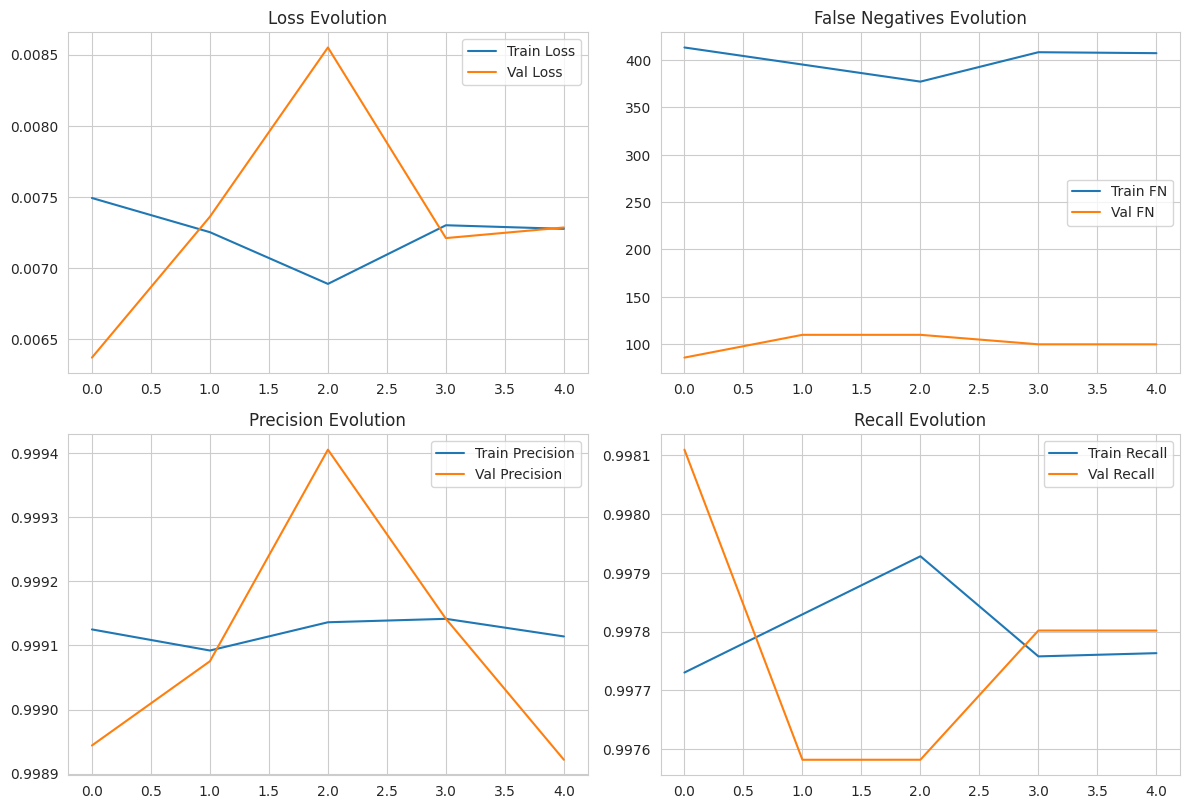

In [ ]:
plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(history['fn'], label='Train FN')
plt.plot(history['val_fn'], label='Val FN')
plt.title('False Negatives Evolution')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(history['precision'], label='Train Precision')
plt.plot(history['val_precision'], label='Val Precision')
plt.title('Precision Evolution')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(history['recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.title('Recall Evolution')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Load data
data = pd.read_csv('/content/drive/MyDrive/Dataset/creditcard_2023.csv')

# Step 2: Define features and target
X = data.drop('Class', axis=1)  # 'Class' is the label column in fraud datasets
y = data['Class']

# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 4: Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Step 7: Evaluation function
def print_score(y_true, y_pred, train=True):
    if train:
        print("Train Result:\n")
    else:
        print("Test Result:\n")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("-" * 50)

# Step 8: Evaluate
print_score(y_train, y_train_pred, train=True)
print_score(y_test, y_test_pred, train=False)

# Step 9: Store F1 scores
scores_dict = {
    'LogisticRegression': {
        'Train': f1_score(y_train, y_train_pred),
        'Test': f1_score(y_test, y_test_pred),
    },
}

print("F1 Score Summary:", scores_dict)


Train Result:

Confusion Matrix:
 [[227261    191]
 [   504 226948]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227452
           1       1.00      1.00      1.00    227452

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904

F1 Score: 0.9984711531904503
--------------------------------------------------
Test Result:

Confusion Matrix:
 [[56805    58]
 [  137 56726]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

F1 Score: 0.9982841606025676
--------------------------------------------------
F1 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use parallel processing and fewer trees for faster training
rf_clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

# Fit the model
rf_clf.fit(X_train, y_train)

# Predict
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

# Evaluate
print_score(y_train, y_train_pred, train=True)
print_score(y_test, y_test_pred, train=False)

# Store scores
scores_dict['Random Forest'] = {
    'Train': f1_score(y_train, y_train_pred),
    'Test': f1_score(y_test, y_test_pred),
}

print("F1 Score Summary:", scores_dict)


Train Result:

Confusion Matrix:
 [[227452      0]
 [     2 227450]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227452
           1       1.00      1.00      1.00    227452

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904

F1 Score: 0.9999956034486549
--------------------------------------------------
Test Result:

Confusion Matrix:
 [[56859     4]
 [   18 56845]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

F1 Score: 0.9998065287744478
--------------------------------------------------
F1 

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Step 1: Create and train the SVM model
svm_model = SVC(kernel='rbf', class_weight='balanced')  # 'balanced' handles class imbalance
svm_model.fit(X_train, y_train)

# Step 2: Predict on test data
y_pred = svm_model.predict(X_test)

# Step 3: Print evaluation report
print("Classification Report (SVM):")
print(classification_report(y_test, y_pred))



Classification Report (SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



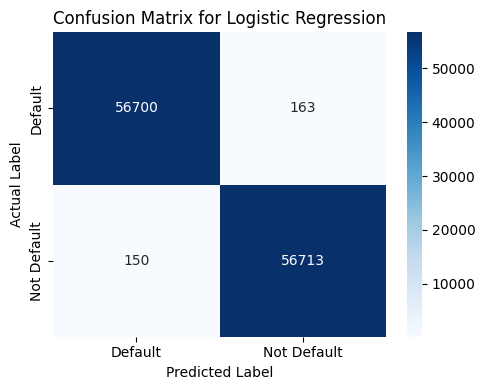

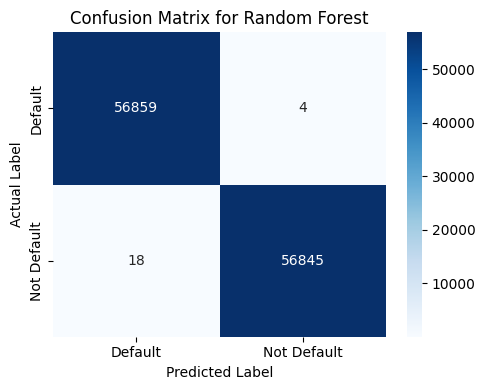

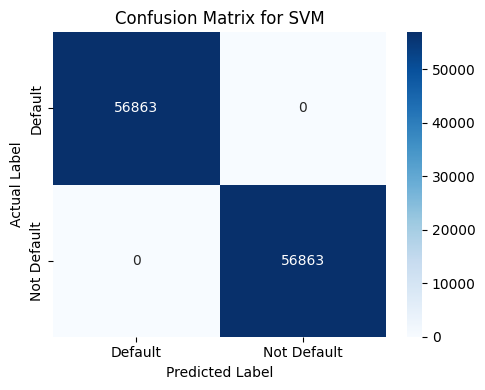

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix data
conf_matrices = {
    "Logistic Regression": np.array([[56700, 163], [150, 56713]]),
    "Random Forest": np.array([[56859, 4], [18, 56845]]),
    "SVM": np.array([[56863, 0], [0, 56863]])
}

# Labels
x_labels = ["Default", "Not Default"]
y_labels = ["Default", "Not Default"]

# Plotting function
def plot_conf_matrix(matrix, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=x_labels, yticklabels=y_labels, cbar=True)
    plt.title(f"Confusion Matrix for {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

# Plot all 3 confusion matrices
for model_name, matrix in conf_matrices.items():
    plot_conf_matrix(matrix, model_name)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Confusion matrix format: [TN, FP, FN, TP]
model_results = {
    "Logistic Regression": [56700, 163, 150, 56713],
    "Random Forest": [56859, 4, 18, 56845],
    "SVM": [56863, 0, 0, 56863]
}

# Function to compute metrics from confusion matrix values
def compute_metrics(tp, fn, fp, tn):
    y_true = np.array([1]*tp + [1]*fn + [0]*fp + [0]*tn)
    y_pred = np.array([1]*tp + [0]*fn + [1]*fp + [0]*tn)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# Apply the function to each model's results
metrics_df = pd.DataFrame({
    model: compute_metrics(tp=vals[3], fn=vals[2], fp=vals[1], tn=vals[0])
    for model, vals in model_results.items()
}).T.round(4)

# Clean and display the DataFrame
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={"index": "Model"}, inplace=True)
print(metrics_df)


                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9972     0.9971  0.9974    0.9972
1        Random Forest    0.9998     0.9999  0.9997    0.9998
2                  SVM    1.0000     1.0000  1.0000    1.0000


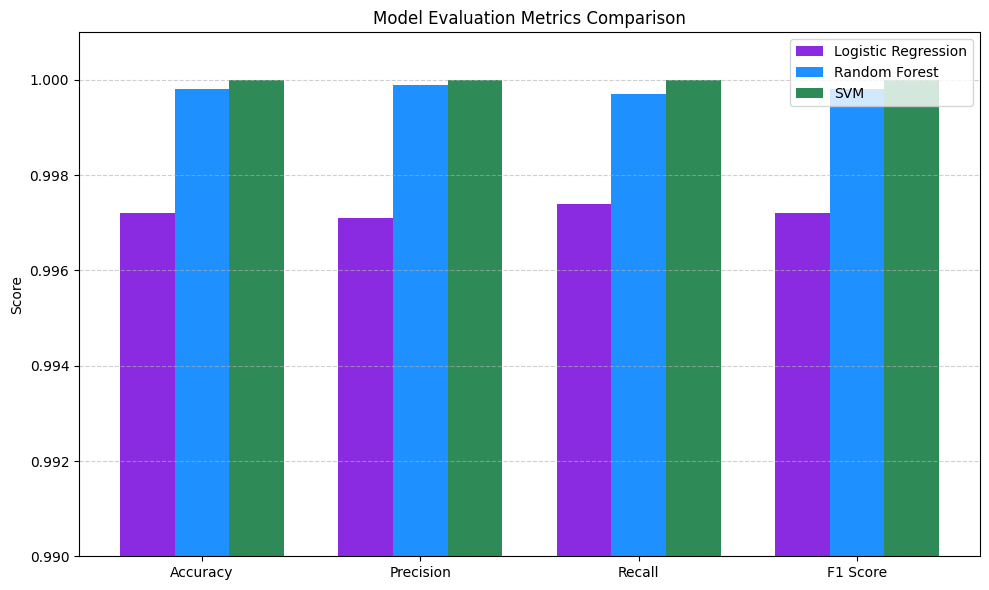

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame with metrics
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [0.9972, 0.9998, 1.0000],
    "Precision": [0.9971, 0.9999, 1.0000],
    "Recall": [0.9974, 0.9997, 1.0000],
    "F1 Score": [0.9972, 0.9998, 1.0000]
})

# List of metrics and colors (Violet, Blue, Green)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#8A2BE2', '#1E90FF', '#2E8B57']  # Violet, Blue, Green

# Plot setup
bar_width = 0.25
x = list(range(len(metrics)))  # [0, 1, 2, 3]

plt.figure(figsize=(10, 6))

# Plot bars for each model
for i, row in metrics_df.iterrows():
    scores = row[metrics]
    bar_positions = [pos + i * bar_width for pos in x]
    plt.bar(bar_positions, scores, width=bar_width, label=row['Model'], color=colors[i])

# Format axes
plt.xticks([r + bar_width for r in x], metrics)
plt.ylim(0.99, 1.001)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()